In [1]:
import pandas as pd

In [9]:
import os 
os.getcwd()
os.chdir('C:/Users/Ddhuy/OneDrive - UGent/DocumentenUGentMaster/SocialMediaAndWebAnalysis/group-project-SMWA')

In [10]:
macros = pd.read_csv('Data\\1_Bronze\\Financials\\macros.csv')
market = pd.read_csv('Data\\1_Bronze\\Financials\\market.csv')

print(f"✓ Loaded {len(macros):,} macros")
print(f"✓ Loaded {len(market):,} market data")
print(f"Dataset macros shape: {macros.shape}")
print(f"Dataset market shape: {market.shape}")

✓ Loaded 4 macros
✓ Loaded 85 market data
Dataset macros shape: (4, 6)
Dataset market shape: (85, 6)


In [11]:
macros

,DATE,RealDisposableIncome,RealGDP,UnemploymentRate,CPIInflation,ConsumerSentiment
0,2024-08-01,17752.9,NaN,4.2,314.062,67.9
1,2024-09-01,17769.9,NaN,4.1,314.732,70.1
2,2024-10-01,17810.5,23586.542,4.1,315.631,70.5
3,2024-11-01,17851.4,NaN,4.2,316.528,71.8


In [12]:
market

,Date,SP500,Oil,VIX,TenYearBond,USDIndex
0,2024-07-05,5567.189941,83.160004,12.480000,4.272,104.879997
1,2024-07-08,5572.850098,82.330002,12.370000,4.269,105.010002
2,2024-07-09,5576.979980,81.410004,12.510000,4.300,105.120003
3,2024-07-10,5633.910156,82.099998,12.850000,4.280,105.050003
4,2024-07-11,5584.540039,82.620003,12.920000,4.193,104.440002
...,...,...,...,...,...,...
80,2024-10-28,5823.520020,67.379997,19.799999,4.278,104.320000
81,2024-10-29,5832.919922,67.209999,19.340000,4.274,104.279999
82,2024-10-30,5813.669922,68.610001,20.350000,4.266,103.989998
83,2024-10-31,5705.450195,69.260002,23.160000,4.284,103.980003


In [14]:
market.dtypes

Date            object
SP500          float64
Oil            float64
VIX            float64
TenYearBond    float64
USDIndex       float64
dtype: object

In [15]:
market['Date'] = pd.to_datetime(market['Date'])
market.dtypes

Date           datetime64[ns]
SP500                 float64
Oil                   float64
VIX                   float64
TenYearBond           float64
USDIndex              float64
dtype: object

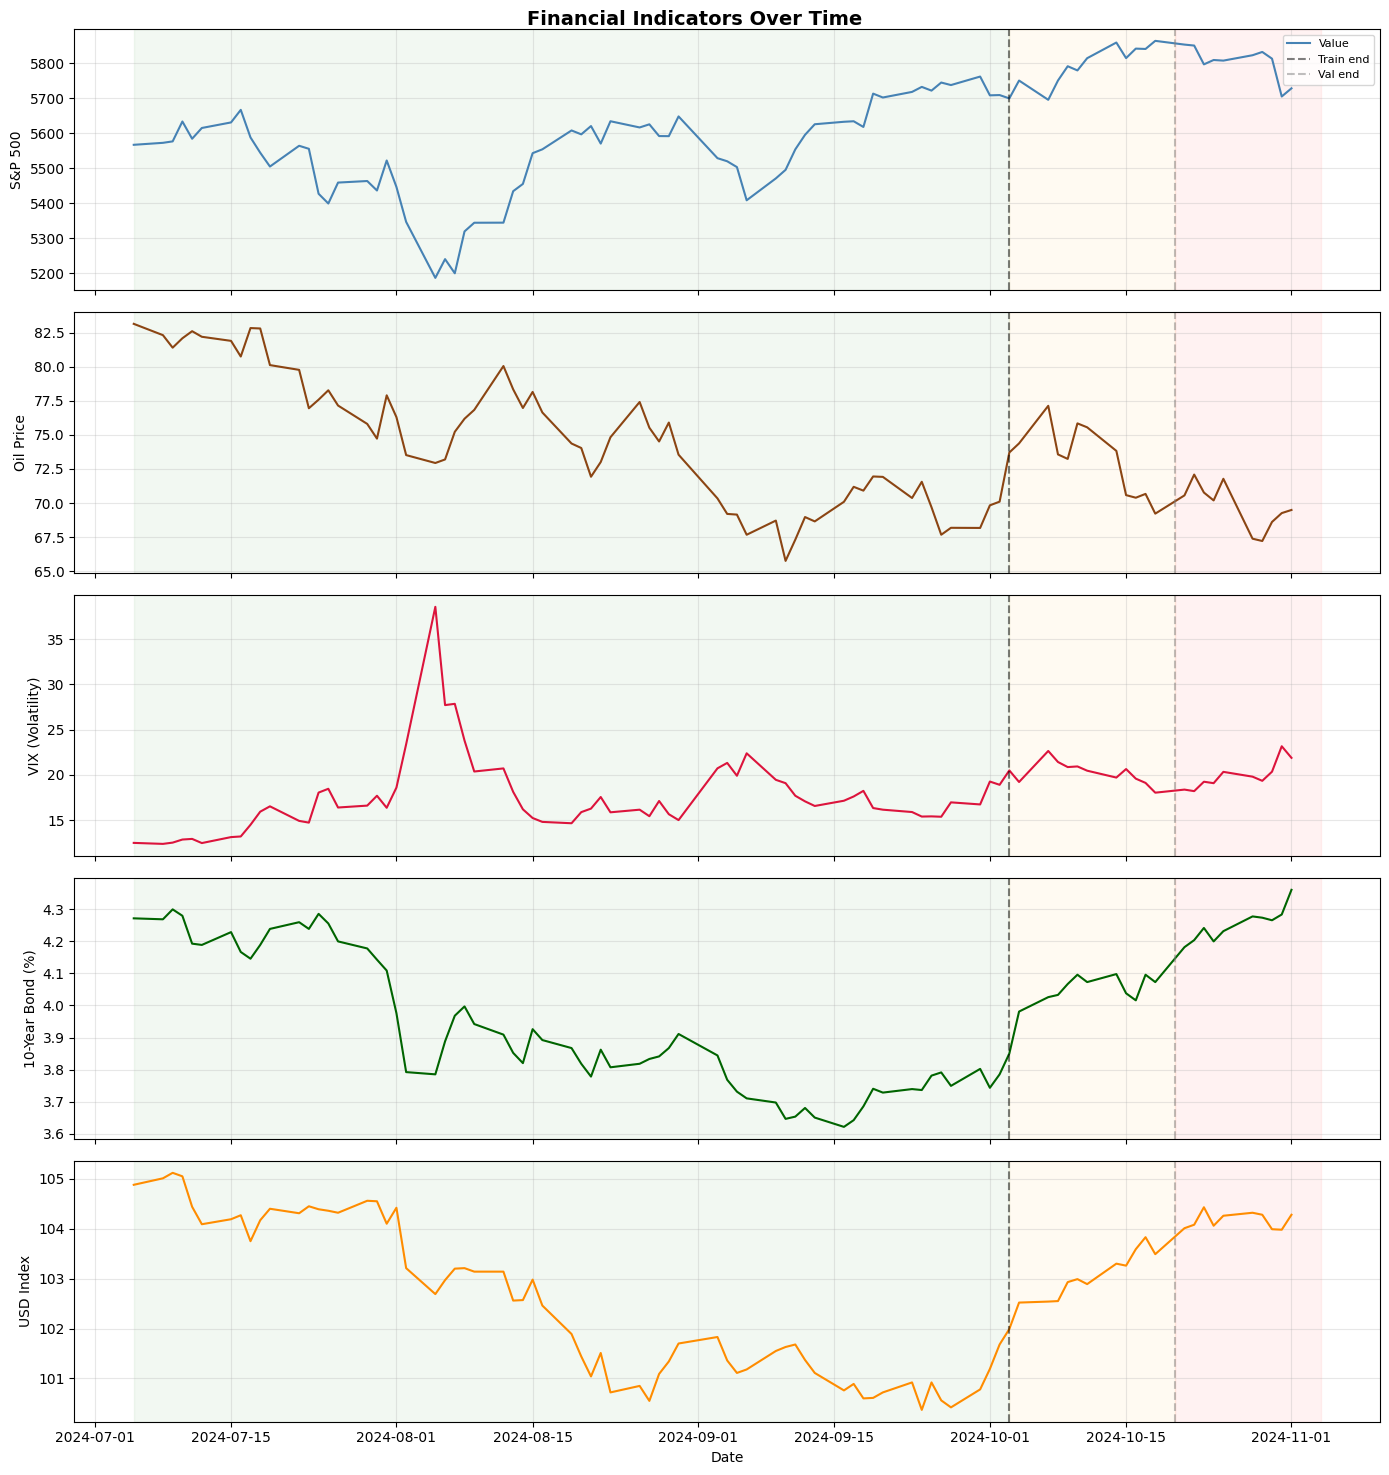

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# ── Plot all financial indicators over time ───────────────────────────────────
fig, axes = plt.subplots(5, 1, figsize=(14, 15), sharex=True)

indicators = {
    'SP500':        ('S&P 500',          'steelblue'),
    'Oil':          ('Oil Price',         'saddlebrown'),
    'VIX':          ('VIX (Volatility)',  'crimson'),
    'TenYearBond':  ('10-Year Bond (%)',  'darkgreen'),
    'USDIndex':     ('USD Index',         'darkorange'),
}

for ax, (col, (label, color)) in zip(axes, indicators.items()):
    ax.plot(market['Date'], market[col], color=color, linewidth=1.5)
    ax.set_ylabel(label, fontsize=10)
    ax.grid(True, alpha=0.3)

    # Train/val/test boundaries
    ax.axvline(pd.Timestamp('2024-10-03'), color='black', linestyle='--', alpha=0.5)
    ax.axvline(pd.Timestamp('2024-10-20'), color='gray',  linestyle='--', alpha=0.5)
    ax.axvspan(pd.Timestamp('2024-07-05'), pd.Timestamp('2024-10-03'), alpha=0.05, color='green')
    ax.axvspan(pd.Timestamp('2024-10-03'), pd.Timestamp('2024-10-20'), alpha=0.05, color='orange')
    ax.axvspan(pd.Timestamp('2024-10-20'), pd.Timestamp('2024-11-04'), alpha=0.05, color='red')

# Add legend once on the first axis
axes[0].legend(['Value', 'Train end', 'Val end'], fontsize=8)

plt.suptitle('Financial Indicators Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.tight_layout()
plt.show()

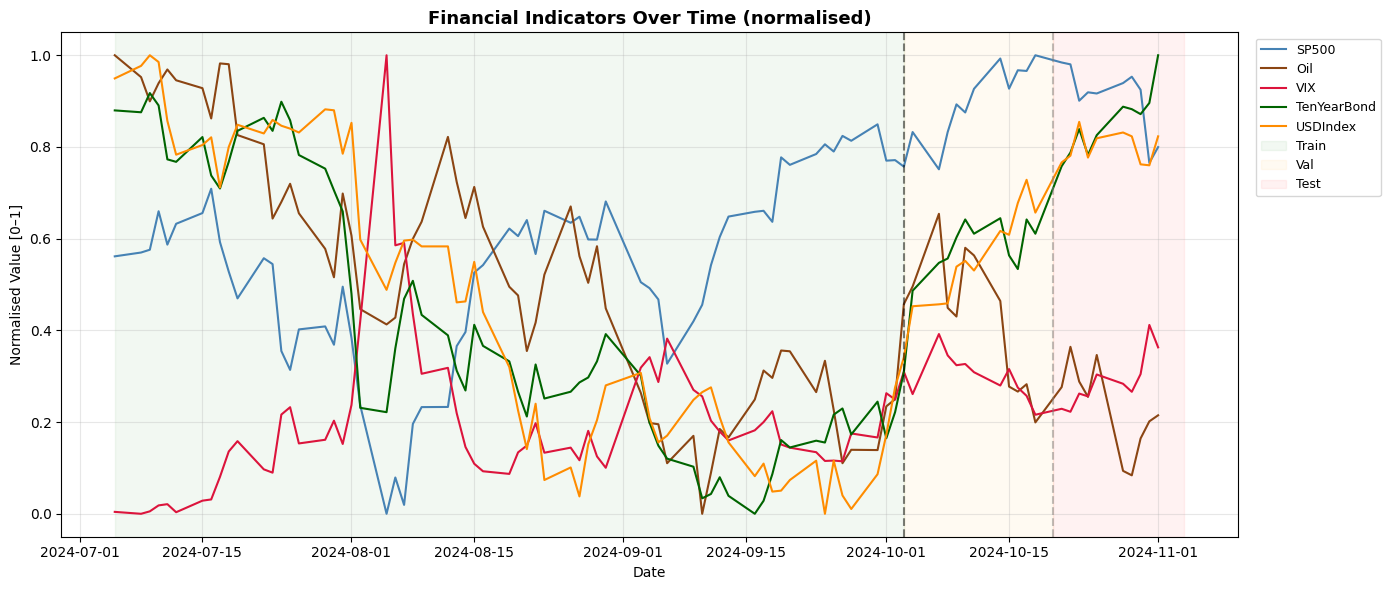

In [18]:
from sklearn.preprocessing import MinMaxScaler

# ── Normalise to [0,1] so all indicators fit on one axis ──────────────────────
scaler = MinMaxScaler()
cols   = ['SP500', 'Oil', 'VIX', 'TenYearBond', 'USDIndex']
normalized = pd.DataFrame(
    scaler.fit_transform(market[cols]),
    columns=cols,
    index=market.index
)
normalized['Date'] = market['Date'].values

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

colors = {'SP500': 'steelblue', 'Oil': 'saddlebrown', 'VIX': 'crimson',
          'TenYearBond': 'darkgreen', 'USDIndex': 'darkorange'}

for col, color in colors.items():
    ax.plot(normalized['Date'], normalized[col], color=color, linewidth=1.5, label=col)

# Train/val/test boundaries
ax.axvline(pd.Timestamp('2024-10-03'), color='black', linestyle='--', alpha=0.5)
ax.axvline(pd.Timestamp('2024-10-20'), color='gray',  linestyle='--', alpha=0.5)
ax.axvspan(pd.Timestamp('2024-07-05'), pd.Timestamp('2024-10-03'), alpha=0.05, color='green',  label='Train')
ax.axvspan(pd.Timestamp('2024-10-03'), pd.Timestamp('2024-10-20'), alpha=0.05, color='orange', label='Val')
ax.axvspan(pd.Timestamp('2024-10-20'), pd.Timestamp('2024-11-04'), alpha=0.05, color='red',    label='Test')

ax.set_xlabel('Date')
ax.set_ylabel('Normalised Value [0–1]')
ax.set_title('Financial Indicators Over Time (normalised)', fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()